In [1]:
# Imports des packages necessaire à l'audit des données

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the data into a DataFrame object
df_telco = pd.read_csv("../data/telco_customer_data_raw.csv")

df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        70000 non-null  object 
 1   gender            69252 non-null  object 
 2   SeniorCitizen     69341 non-null  object 
 3   Partner           66470 non-null  object 
 4   Dependents        66435 non-null  object 
 5   tenure            69433 non-null  float64
 6   PhoneService      70000 non-null  object 
 7   MultipleLines     68132 non-null  object 
 8   InternetService   70000 non-null  object 
 9   OnlineSecurity    67078 non-null  object 
 10  OnlineBackup      67253 non-null  object 
 11  DeviceProtection  67106 non-null  object 
 12  TechSupport       67267 non-null  object 
 13  StreamingTV       67173 non-null  object 
 14  StreamingMovies   67215 non-null  object 
 15  Contract          70000 non-null  object 
 16  PaperlessBilling  70000 non-null  object

In [3]:
# Creating a copy of the DataFrame to perform data cleaning
df_telco_clean = df_telco.copy()

# Viewing first lines to ensure copy went well
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        70000 non-null  object 
 1   gender            69252 non-null  object 
 2   SeniorCitizen     69341 non-null  object 
 3   Partner           66470 non-null  object 
 4   Dependents        66435 non-null  object 
 5   tenure            69433 non-null  float64
 6   PhoneService      70000 non-null  object 
 7   MultipleLines     68132 non-null  object 
 8   InternetService   70000 non-null  object 
 9   OnlineSecurity    67078 non-null  object 
 10  OnlineBackup      67253 non-null  object 
 11  DeviceProtection  67106 non-null  object 
 12  TechSupport       67267 non-null  object 
 13  StreamingTV       67173 non-null  object 
 14  StreamingMovies   67215 non-null  object 
 15  Contract          70000 non-null  object 
 16  PaperlessBilling  70000 non-null  object

### Cleaning the gender column

In [4]:
# Viewing the column type
df_telco_clean["gender"].dtype

dtype('O')

#### Viewing the data, we can see that there are inconsistencies in :
    - Category values

#### Let us fix that !

In [6]:
# Remplacing inconsistent category values
df_telco_clean["gender"] = df_telco_clean["gender"].replace(
    {
        "Man": "Male",
        "male": "Male",
        "FEMALE": "Female",
        "m": "Male",
        "f": "Female"
    }
)

In [7]:
# Checking if all went fine
df_telco_clean["gender"].value_counts(dropna=False)

gender
Female    34787
Male      34465
NaN         748
Name: count, dtype: int64

##### Let's deal with the missing values for the column

In [8]:
# Viewing the quantity of missing values for the column
df_telco_clean["gender"].value_counts(normalize=True, dropna=False)*100

gender
Female    49.695714
Male      49.235714
NaN        1.068571
Name: proportion, dtype: float64

In [9]:
# Since we only have 1% of missing values, we can impute with the columns mode
df_telco_clean["gender"].fillna(df_telco_clean["gender"].mode()[0], inplace=True)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/3133337517.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["gender"].fillna(df_telco_clean["gender"].mode()[0], inplace=True)


In [10]:
# Viewing the quantity of missing values for the column
df_telco_clean["gender"].value_counts(normalize=True, dropna=False)*100

gender
Female    50.764286
Male      49.235714
Name: proportion, dtype: float64

In [11]:
df_telco_clean["gender"].value_counts(normalize=False, dropna=False)

gender
Female    35535
Male      34465
Name: count, dtype: int64

In [12]:
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen        659
Partner             3530
Dependents          3565
tenure               567
PhoneService           0
MultipleLines       1868
InternetService        0
OnlineSecurity      2922
OnlineBackup        2747
DeviceProtection    2894
TechSupport         2733
StreamingTV         2827
StreamingMovies     2785
Contract               0
PaperlessBilling       0
PaymentMethod       3569
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

### Cleaning the SeniorCitizen column

In [13]:
# Viewing the column type
df_telco_clean["SeniorCitizen"].dtype

dtype('O')

In [14]:
# Having count of distinct values
df_telco_clean["SeniorCitizen"].value_counts(dropna=False)

SeniorCitizen
0             52405
1             10388
Yes            3559
No             2739
NaN             659
not senior      250
Name: count, dtype: int64

In [15]:
# Replacing inconsistent categories
df_telco_clean["SeniorCitizen"] = df_telco_clean["SeniorCitizen"].replace(
    {
        "0": 0,
        "1": 1,
        "Yes": 1,
        "No": 0,
        "not senior": 0
    }
)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/3914732092.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_telco_clean["SeniorCitizen"] = df_telco_clean["SeniorCitizen"].replace(


In [16]:
# Checking if replacing incosistent values worked
df_telco_clean["SeniorCitizen"].value_counts(dropna=False)

SeniorCitizen
0.0    55394
1.0    13947
NaN      659
Name: count, dtype: int64

In [17]:
# Re-checking dtype for SenoirCitizen
df_telco_clean["SeniorCitizen"].dtype

dtype('float64')

In [18]:
# Converting SenoirCitizen column data type to Int8
# This is a format that is memory efficient and easily interpreted by ML models
df_telco_clean["SeniorCitizen"] = df_telco_clean["SeniorCitizen"].astype("Int8")

# Checking
df_telco_clean["SeniorCitizen"].dtype

Int8Dtype()

In [19]:
# Checking if type casting worked
df_telco_clean["SeniorCitizen"].value_counts(dropna=False, normalize=True)

SeniorCitizen
0       0.791343
1       0.199243
<NA>    0.009414
Name: proportion, dtype: Float64

In [20]:
# Having a look at the distinct values in the Senoir
df_telco_clean["SeniorCitizen"].unique()[:10]

<IntegerArray>
[0, 1, <NA>]
Length: 3, dtype: Int8

In [21]:
# Viewing first few lines with missing values
df_telco_clean[df_telco_clean["SeniorCitizen"].isna()].head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
74,CUST00075,Female,<NA>,Yes,No,-10.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),19.46,0,Yes
94,CUST00095,Female,<NA>,No,No,4.0,Yes,No,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),32.73,130.92,Yes
392,CUST00393,Female,<NA>,No,No,53.0,Yes,Yes,Fiber optic,Yes,...,No,No,No,No,Two year,Yes,Mailed check,37.40,1982.2,No
581,CUST00582,Male,<NA>,Yes,No,7.0,No,No phone service,Fiber optic,No,...,No,Yes,No,Yes,One year,Yes,Electronic check,36.07,252.49,No
694,CUST00695,Male,<NA>,Yes,No,32.0,Yes,No,DSL,Yes,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,31.57,1010.24,Yes


In [22]:
# Imputing with the mode since given the very low rate of missing value in the column, the mode is unlikely to create bias
df_telco_clean["SeniorCitizen"].fillna(df_telco_clean["SeniorCitizen"].mode()[0], inplace=True)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/4265553396.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["SeniorCitizen"].fillna(df_telco_clean["SeniorCitizen"].mode()[0], inplace=True)


In [23]:
# Checking if there are still missing values
df_telco_clean["SeniorCitizen"].value_counts(dropna=False)

SeniorCitizen
0    56053
1    13947
Name: count, dtype: Int64

In [24]:
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner             3530
Dependents          3565
tenure               567
PhoneService           0
MultipleLines       1868
InternetService        0
OnlineSecurity      2922
OnlineBackup        2747
DeviceProtection    2894
TechSupport         2733
StreamingTV         2827
StreamingMovies     2785
Contract               0
PaperlessBilling       0
PaymentMethod       3569
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

### Cleaning the Partner column

In [25]:
# Viewing the column data type
df_telco_clean["Partner"].dtype

dtype('O')

In [26]:
# Viewing column values
df_telco_clean["Partner"].value_counts(dropna=False)

Partner
No     38344
Yes    28126
NaN     3530
Name: count, dtype: int64

In [27]:
# Converting to integers 0/1
df_telco_clean["Partner"].replace(
    {
        "No": 0,
        "Yes": 1
    }, inplace=True
)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/429660734.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["Partner"].replace(
/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/429660734.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_telco_cl

In [28]:
# Viewing column new values
df_telco_clean["Partner"].value_counts(dropna=False)

Partner
0.0    38344
1.0    28126
NaN     3530
Name: count, dtype: int64

In [29]:
# Casting values to pandas Int8
df_telco_clean["Partner"] = df_telco_clean["Partner"].astype("Int8")

# Checking all went well
df_telco_clean["Partner"].dtype

Int8Dtype()

In [30]:
# Viewing column new values
df_telco_clean["Partner"].value_counts(dropna=False)

Partner
0       38344
1       28126
<NA>     3530
Name: count, dtype: Int64

In [31]:
# Proportion of missing values
df_telco_clean["Partner"].value_counts(dropna=False, normalize=True)

Partner
0       0.547771
1         0.4018
<NA>    0.050429
Name: proportion, dtype: Float64

In [32]:
# Imputing the missing values with the mode
df_telco_clean["Partner"].fillna(
    df_telco_clean["Partner"].mode()[0],
    inplace=True
)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/41495706.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["Partner"].fillna(


In [33]:
# Checking back proportion of missing values
df_telco_clean["Partner"].value_counts(dropna=False, normalize=True)

Partner
0    0.5982
1    0.4018
Name: proportion, dtype: Float64

In [34]:
# Viewing back all column for the number of missing values
df_telco_clean.isna().sum(axis= 0)

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents          3565
tenure               567
PhoneService           0
MultipleLines       1868
InternetService        0
OnlineSecurity      2922
OnlineBackup        2747
DeviceProtection    2894
TechSupport         2733
StreamingTV         2827
StreamingMovies     2785
Contract               0
PaperlessBilling       0
PaymentMethod       3569
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

### Cleaning the Dependents

In [35]:
# Viewing the column data type
df_telco_clean["Dependents"].dtype

dtype('O')

In [36]:
# Viewing column values
df_telco_clean["Dependents"].value_counts(dropna=False)

Dependents
No     45375
Yes    21060
NaN     3565
Name: count, dtype: int64

In [37]:
# Unique values
df_telco_clean["Dependents"].unique()

array(['Yes', 'No', nan], dtype=object)

In [38]:
# Converting values to 1/0
df_telco_clean["Dependents"].replace(
    {
        "No": 0,
        "Yes": 1
    }, inplace=True
)

# Checking if replacement worked
df_telco_clean["Dependents"].value_counts()

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/1662902225.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["Dependents"].replace(
/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/1662902225.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_tel

Dependents
0.0    45375
1.0    21060
Name: count, dtype: int64

In [39]:
# Casting to Int8, format that is memory efficient
df_telco_clean["Dependents"] = df_telco_clean["Dependents"].astype("Int8")

# Checking all worked
df_telco_clean["Dependents"].dtype

Int8Dtype()

In [40]:
# Checking ne value list
df_telco_clean["Dependents"].value_counts(dropna=False)

Dependents
0       45375
1       21060
<NA>     3565
Name: count, dtype: Int64

In [41]:
# Proportion of missing values
df_telco_clean["Dependents"].value_counts(dropna=False, normalize=True)*100

Dependents
0       64.821429
1       30.085714
<NA>     5.092857
Name: proportion, dtype: Float64

In [42]:
# Replacing missing values with the mode
df_telco_clean["Dependents"].fillna(
    df_telco_clean["Dependents"].mode()[0],
    inplace=True
)

# Checking if there are still missing values
df_telco_clean["Dependents"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/1732301673.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["Dependents"].fillna(


Dependents
0    48940
1    21060
Name: count, dtype: Int64

In [43]:
# Global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure               567
PhoneService           0
MultipleLines       1868
InternetService        0
OnlineSecurity      2922
OnlineBackup        2747
DeviceProtection    2894
TechSupport         2733
StreamingTV         2827
StreamingMovies     2785
Contract               0
PaperlessBilling       0
PaymentMethod       3569
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

### Cleaning the tenure column

In [44]:
# Viewing column data type
df_telco_clean["tenure"].dtype

dtype('float64')

In [45]:
# General descriptive statistics
df_telco_clean["tenure"].describe()

count    69433.000000
mean        30.516858
std         89.873767
min        -10.000000
25%         10.000000
50%         20.000000
75%         35.000000
max        999.000000
Name: tenure, dtype: float64

**We can see that there are invalid tenure values**
- The values in cause here are the negative ones since tenure values represents the number of months a customer stayed with the company

**We are going to investigate and observe if there are inconsistencies**

In [46]:
# Showing first few rows of the data with missing values
df_telco_clean[df_telco_clean["tenure"].isna()].head(10)
 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
61,CUST00062,Male,0,1,0,NaN,Yes,No,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,49.13,0,Yes
145,CUST00146,Female,0,0,0,NaN,Yes,Yes,Fiber optic,No,...,No,No,No internet service,No,Two year,No,Bank transfer (automatic),77.77,pending,Yes
259,CUST00260,Male,0,0,0,NaN,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),40.50,0,Yes
352,CUST00353,Female,0,0,0,NaN,Yes,No,Fiber optic,No,...,No,Yes,Yes,NaN,Month-to-month,Yes,Electronic check,24.07,0,Yes
399,CUST00400,Female,1,1,0,NaN,Yes,NaN,Fiber optic,No,...,No,No,No internet service,No,Month-to-month,Yes,Bank transfer (automatic),24.34,0,Yes
683,CUST00684,Male,0,1,1,NaN,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,20.08,0,Yes
724,CUST00725,Female,0,1,0,NaN,Yes,Yes,Fiber optic,Yes,...,Yes,No,No,No,One year,Yes,Credit card (automatic),110.31,pending,No
742,CUST00743,Female,0,1,0,NaN,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,87.60,0,No
955,CUST00956,Female,0,0,0,NaN,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Electronic check,29.45,0,No
1024,CUST01025,Female,0,0,0,NaN,No,No phone service,DSL,Yes,...,No,No,No,NaN,Month-to-month,Yes,Bank transfer (automatic),33.42,0,Yes


In [47]:
# Showing the first rows of data without missing values in the tenure column
df_telco_clean[df_telco_clean["tenure"].notna()].head(10)
 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,0,1,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1,1,0,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No
2,CUST00003,Female,0,0,0,42.0,Yes,Yes,DSL,No,...,No,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0,0,1,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
4,CUST00005,Male,1,1,1,17.0,Yes,NaN,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes
5,CUST00006,Male,0,1,0,18.0,Yes,No,Fiber optic,No,...,NaN,Yes,NaN,No,One year,No,Electronic check,37.23,670.14,Yes
6,CUST00007,Female,0,0,0,25.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,67.47,1686.75,No
7,CUST00008,Female,0,1,0,33.0,Yes,Yes,Fiber optic,No,...,No,No,No,NaN,Two year,No,Electronic check,76.30,2517.9,No
8,CUST00009,Female,0,1,0,6.0,Yes,Yes,DSL,Yes,...,No,No internet service,No,No internet service,Month-to-month,No,Electronic check,64.86,389.16,No
9,CUST00010,Female,0,1,0,-5.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.60,0,Yes


In [48]:
# Cleaning total charge and storing in a temporary variable
temp_total_charges = df_telco_clean["TotalCharges"].str.replace(r'[^0-9.]', "", regex=True)

In [49]:
# Having an overlook of possible values
temp_total_charges.value_counts()

TotalCharges
0          1262
            162
484.8         8
554.4         8
429.66        8
           ... 
469.14        1
1701.44       1
98.14         1
1216.08       1
217.23        1
Name: count, Length: 49964, dtype: int64

In [50]:
# Verifying if the presence of any comma
temp_total_charges.loc[temp_total_charges.str.contains(",", na=False)]

Series([], Name: TotalCharges, dtype: object)

In [51]:
# Converting to numeric
temp_total_charges = pd.to_numeric(temp_total_charges, errors='coerce')

In [52]:
# Verifying data type
temp_total_charges.dtype

dtype('float64')

In [53]:
# Checking back possible values
temp_total_charges.value_counts(dropna=False)

TotalCharges
0.00       1262
NaN        1224
484.80        8
429.66        8
439.20        8
           ... 
469.14        1
1701.44       1
98.14         1
1216.08       1
217.23        1
Name: count, Length: 49964, dtype: int64

In [54]:
# Checking if there are incosistencies in MonthlyCharges/TotalCharges pair given NaN or negative values of tenure
df_telco_clean[(df_telco_clean["MonthlyCharges"] > temp_total_charges) & (df_telco_clean["tenure"].isna() | (df_telco_clean["tenure"] <= 0))].head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
9,CUST00010,Female,0,1,0,-5.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.60,0,Yes
20,CUST00021,Male,0,0,1,-10.0,Yes,No,Fiber optic,No,...,Yes,Yes,No internet service,Yes,Month-to-month,Yes,Electronic check,102.35,0,Yes
61,CUST00062,Male,0,1,0,NaN,Yes,No,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,49.13,0,Yes
74,CUST00075,Female,0,1,0,-10.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),19.46,0,Yes
82,CUST00083,Male,0,0,1,-5.0,Yes,Yes,Fiber optic,No,...,No,Yes,No,No,Two year,Yes,Electronic check,99.35,0,No
128,CUST00129,Male,0,1,0,-10.0,Yes,Yes,DSL,NaN,...,No,No,No,No internet service,Month-to-month,Yes,Bank transfer (automatic),66.32,0,Yes
192,CUST00193,Female,1,0,0,-5.0,Yes,Yes,Fiber optic,No,...,No,Yes,No internet service,Yes,Month-to-month,Yes,Bank transfer (automatic),35.30,0,Yes
259,CUST00260,Male,0,0,0,NaN,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),40.50,0,Yes
300,CUST00301,Female,1,1,0,-5.0,Yes,No,DSL,Yes,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,54.58,0,Yes
352,CUST00353,Female,0,0,0,NaN,Yes,No,Fiber optic,No,...,No,Yes,Yes,NaN,Month-to-month,Yes,Electronic check,24.07,0,Yes


- This shows inconsistencies when either tenure value is negative or lacking since we have MonthlyCharges > TotalCharges there
- So we can drop does rows since they have no sense

In [55]:
# Dropping rows where tenure is NaN and less than 0
df_telco_clean = df_telco_clean[df_telco_clean["tenure"].notna() & (df_telco_clean["tenure"] > 0)]

In [56]:
# Viewing entire data frame info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  object 
 7   MultipleLines     66454 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    65424 non-null  object 
 10  OnlineBackup      65588 non-null  object 
 11  DeviceProtection  65452 non-null  object 
 12  TechSupport       65604 non-null  object 
 13  StreamingTV       65525 non-null  object 
 14  StreamingMovies   65557 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [57]:
# Viewing entire dataframe missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines       1817
InternetService        0
OnlineSecurity      2847
OnlineBackup        2683
DeviceProtection    2819
TechSupport         2667
StreamingTV         2746
StreamingMovies     2714
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning PhoneService column

In [58]:
# Viewing column data type
df_telco_clean["PhoneService"].dtype

dtype('O')

In [59]:
# Showing column's different values
df_telco_clean["PhoneService"].value_counts(dropna=False)

PhoneService
Yes    61469
No      6802
Name: count, dtype: int64

In [60]:
# List of unique values
df_telco_clean["PhoneService"].unique()

array(['Yes', 'No'], dtype=object)

In [61]:
# Mapping values to 1/0 then casting to Int8
df_telco_clean["PhoneService"] = df_telco_clean["PhoneService"].replace({"Yes": 1, "No": 0}).astype("Int8")

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/749675044.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_telco_clean["PhoneService"] = df_telco_clean["PhoneService"].replace({"Yes": 1, "No": 0}).astype("Int8")


In [62]:
# Checking if cleaning worked
df_telco_clean["PhoneService"].value_counts(dropna=False)

PhoneService
1    61469
0     6802
Name: count, dtype: Int64

In [63]:
df_telco_clean["PhoneService"].dtype

Int8Dtype()

In [64]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     66454 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    65424 non-null  object 
 10  OnlineBackup      65588 non-null  object 
 11  DeviceProtection  65452 non-null  object 
 12  TechSupport       65604 non-null  object 
 13  StreamingTV       65525 non-null  object 
 14  StreamingMovies   65557 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [65]:
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines       1817
InternetService        0
OnlineSecurity      2847
OnlineBackup        2683
DeviceProtection    2819
TechSupport         2667
StreamingTV         2746
StreamingMovies     2714
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the MultipleLines column

In [66]:
# Checking the column's dtype
df_telco_clean["MultipleLines"].dtype

dtype('O')

In [67]:
# Checking the possible values for the variable
df_telco_clean["MultipleLines"].value_counts(dropna=False)

MultipleLines
Yes                 33861
No                  24551
No phone service     8042
NaN                  1817
Name: count, dtype: int64

In [68]:
df_telco_clean["MultipleLines"].unique()

array(['Yes', nan, 'No', 'No phone service'], dtype=object)

In [69]:
# Viewing the number of missing values
df_telco_clean["MultipleLines"].value_counts(dropna=False, normalize=False)

MultipleLines
Yes                 33861
No                  24551
No phone service     8042
NaN                  1817
Name: count, dtype: int64

In [70]:
# Viewing the percentage of missing values
df_telco_clean["MultipleLines"].value_counts(dropna=False, normalize=True)

MultipleLines
Yes                 0.495979
No                  0.359611
No phone service    0.117795
NaN                 0.026615
Name: proportion, dtype: float64

In [71]:
# Since we have <2% of missing values, we can impute with the column's mode
df_telco_clean["MultipleLines"] = df_telco_clean["MultipleLines"].fillna(df_telco_clean["MultipleLines"].mode()[0])

In [72]:
# Checking backing back the number of missing values
df_telco_clean["MultipleLines"].value_counts(dropna=False, normalize=False)

MultipleLines
Yes                 35678
No                  24551
No phone service     8042
Name: count, dtype: int64

In [73]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    65424 non-null  object 
 10  OnlineBackup      65588 non-null  object 
 11  DeviceProtection  65452 non-null  object 
 12  TechSupport       65604 non-null  object 
 13  StreamingTV       65525 non-null  object 
 14  StreamingMovies   65557 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [74]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity      2847
OnlineBackup        2683
DeviceProtection    2819
TechSupport         2667
StreamingTV         2746
StreamingMovies     2714
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the InternetService column

In [75]:
# Checking the column's dtype
df_telco_clean["InternetService"].dtype

dtype('O')

In [76]:
# Checking the column's values
df_telco_clean["InternetService"].value_counts(dropna=False)

InternetService
Fiber optic    37552
DSL            17152
No             13567
Name: count, dtype: int64

In [77]:
df_telco_clean["InternetService"].unique()

array(['No', 'DSL', 'Fiber optic'], dtype=object)

- Nothing to clean here

In [78]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity      2847
OnlineBackup        2683
DeviceProtection    2819
TechSupport         2667
StreamingTV         2746
StreamingMovies     2714
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the OnlineSecurity column

In [79]:
# Checking column's type
df_telco_clean["OnlineSecurity"].dtype

dtype('O')

In [80]:
# Viewing the column's values
df_telco_clean["OnlineSecurity"].value_counts(dropna=False)

OnlineSecurity
No                     38225
No internet service    16269
Yes                    10922
NaN                     2847
True                       5
Y                          3
Name: count, dtype: int64

In [81]:
df_telco_clean["OnlineSecurity"].unique()

array(['No internet service', 'No', 'Yes', nan, 'Y', 'True'], dtype=object)

In [82]:
# Correcting inconsistencies before dealing with values
df_telco_clean["OnlineSecurity"].replace(
    {
        "True": "Yes",
        "Y": "Yes"
    },
    inplace=True
)

# Checking if all worked
df_telco_clean["OnlineSecurity"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/438355832.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["OnlineSecurity"].replace(


OnlineSecurity
No                     38225
No internet service    16269
Yes                    10930
NaN                     2847
Name: count, dtype: int64

In [83]:
# Viewing percentage of missing values
df_telco_clean["OnlineSecurity"].value_counts(dropna=False, normalize=True)

OnlineSecurity
No                     0.559901
No internet service    0.238300
Yes                    0.160097
NaN                    0.041701
Name: proportion, dtype: float64

In [84]:
# Imputing missing values with the mode since we just have 4% of missing values at random
df_telco_clean["OnlineSecurity"].fillna(df_telco_clean["OnlineSecurity"].mode()[0], inplace=True)

In [85]:
# Checking back for missing values
df_telco_clean["OnlineSecurity"].value_counts(dropna=False)

OnlineSecurity
No                     41072
No internet service    16269
Yes                    10930
Name: count, dtype: int64

In [86]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    68271 non-null  object 
 10  OnlineBackup      65588 non-null  object 
 11  DeviceProtection  65452 non-null  object 
 12  TechSupport       65604 non-null  object 
 13  StreamingTV       65525 non-null  object 
 14  StreamingMovies   65557 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [87]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup        2683
DeviceProtection    2819
TechSupport         2667
StreamingTV         2746
StreamingMovies     2714
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the OnlineSecurity column

In [88]:
# Checking column's type
df_telco_clean["OnlineBackup"].dtype

dtype('O')

In [89]:
# Viewing the column's values
df_telco_clean["OnlineBackup"].value_counts(dropna=False)

OnlineBackup
No                     38312
No internet service    16288
Yes                    10971
NaN                     2683
Y                         10
True                       7
Name: count, dtype: int64

In [90]:
# Correcting inconsistencies before dealing with values
df_telco_clean["OnlineBackup"].replace(
    {
        "True": "Yes",
        "Y": "Yes"
    },
    inplace=True
)

# Checking if all worked
df_telco_clean["OnlineBackup"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/2995859415.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["OnlineBackup"].replace(


OnlineBackup
No                     38312
No internet service    16288
Yes                    10988
NaN                     2683
Name: count, dtype: int64

In [91]:
# Imputing missing values with the mode since we just have 4% of missing values at random
df_telco_clean["OnlineBackup"].fillna(df_telco_clean["OnlineBackup"].mode()[0], inplace=True)

# Checking back for missing values
df_telco_clean["OnlineBackup"].value_counts(dropna=False)

OnlineBackup
No                     40995
No internet service    16288
Yes                    10988
Name: count, dtype: int64

In [92]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    68271 non-null  object 
 10  OnlineBackup      68271 non-null  object 
 11  DeviceProtection  65452 non-null  object 
 12  TechSupport       65604 non-null  object 
 13  StreamingTV       65525 non-null  object 
 14  StreamingMovies   65557 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [93]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection    2819
TechSupport         2667
StreamingTV         2746
StreamingMovies     2714
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the DeviceProtection column

In [94]:
# Checking column's type
df_telco_clean["DeviceProtection"].dtype

dtype('O')

In [95]:
# Viewing the column's values
df_telco_clean["DeviceProtection"].value_counts(dropna=False)

DeviceProtection
No                     38222
No internet service    16215
Yes                    11008
NaN                     2819
Y                          6
True                       1
Name: count, dtype: int64

In [96]:
# Correcting inconsistencies before dealing with values
df_telco_clean["DeviceProtection"].replace(
    {
        "True": "Yes",
        "Y": "Yes"
    },
    inplace=True
)

# Checking if all worked
df_telco_clean["DeviceProtection"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/4273969735.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["DeviceProtection"].replace(


DeviceProtection
No                     38222
No internet service    16215
Yes                    11015
NaN                     2819
Name: count, dtype: int64

In [97]:
# Imputing missing values with the mode since we just have 4% of missing values at random
df_telco_clean["DeviceProtection"].fillna(df_telco_clean["DeviceProtection"].mode()[0], inplace=True)

# Checking back for missing values
df_telco_clean["DeviceProtection"].value_counts(dropna=False)

DeviceProtection
No                     41041
No internet service    16215
Yes                    11015
Name: count, dtype: int64

In [98]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    68271 non-null  object 
 10  OnlineBackup      68271 non-null  object 
 11  DeviceProtection  68271 non-null  object 
 12  TechSupport       65604 non-null  object 
 13  StreamingTV       65525 non-null  object 
 14  StreamingMovies   65557 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [99]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport         2667
StreamingTV         2746
StreamingMovies     2714
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the TechSupport column

In [100]:
# Checking column's type
df_telco_clean["TechSupport"].dtype

dtype('O')

In [101]:
# Viewing the column's values
df_telco_clean["TechSupport"].value_counts(dropna=False)

TechSupport
No                     38441
No internet service    16209
Yes                    10943
NaN                     2667
Y                          7
True                       4
Name: count, dtype: int64

In [102]:
# Correcting inconsistencies before dealing with values
df_telco_clean["TechSupport"].replace(
    {
        "True": "Yes",
        "Y": "Yes"
    },
    inplace=True
)

# Checking if all worked
df_telco_clean["TechSupport"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/2405672972.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["TechSupport"].replace(


TechSupport
No                     38441
No internet service    16209
Yes                    10954
NaN                     2667
Name: count, dtype: int64

In [103]:
# Imputing missing values with the mode since we just have 4% of missing values at random
df_telco_clean["TechSupport"].fillna(df_telco_clean["TechSupport"].mode()[0], inplace=True)

# Checking back for missing values
df_telco_clean["TechSupport"].value_counts(dropna=False)

TechSupport
No                     41108
No internet service    16209
Yes                    10954
Name: count, dtype: int64

In [104]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    68271 non-null  object 
 10  OnlineBackup      68271 non-null  object 
 11  DeviceProtection  68271 non-null  object 
 12  TechSupport       68271 non-null  object 
 13  StreamingTV       65525 non-null  object 
 14  StreamingMovies   65557 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [105]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         2746
StreamingMovies     2714
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the StreamingTV column

In [106]:
# Checking column's type
df_telco_clean["StreamingTV"].dtype

dtype('O')

In [107]:
# Viewing the column's values
df_telco_clean["StreamingTV"].value_counts(dropna=False)

StreamingTV
No                     38213
No internet service    16209
Yes                    11094
NaN                     2746
True                       5
Y                          4
Name: count, dtype: int64

In [108]:
# Correcting inconsistencies before dealing with values
df_telco_clean["StreamingTV"].replace(
    {
        "True": "Yes",
        "Y": "Yes"
    },
    inplace=True
)

# Checking if all worked
df_telco_clean["StreamingTV"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/2230987544.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["StreamingTV"].replace(


StreamingTV
No                     38213
No internet service    16209
Yes                    11103
NaN                     2746
Name: count, dtype: int64

In [109]:
# Imputing missing values with the mode since we just have 4% of missing values at random
df_telco_clean["StreamingTV"].fillna(df_telco_clean["StreamingTV"].mode()[0], inplace=True)

# Checking back for missing values
df_telco_clean["StreamingTV"].value_counts(dropna=False)

StreamingTV
No                     40959
No internet service    16209
Yes                    11103
Name: count, dtype: int64

In [110]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    68271 non-null  object 
 10  OnlineBackup      68271 non-null  object 
 11  DeviceProtection  68271 non-null  object 
 12  TechSupport       68271 non-null  object 
 13  StreamingTV       68271 non-null  object 
 14  StreamingMovies   65557 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [111]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies     2714
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the StreamingMovies column

In [112]:
# Checking column's type
df_telco_clean["StreamingMovies"].dtype

dtype('O')

In [113]:
# Viewing the column's values
df_telco_clean["StreamingMovies"].value_counts(dropna=False)

StreamingMovies
No                     38208
No internet service    16341
Yes                    10997
NaN                     2714
Y                          7
True                       4
Name: count, dtype: int64

In [114]:
# Correcting inconsistencies before dealing with values
df_telco_clean["StreamingMovies"].replace(
    {
        "True": "Yes",
        "Y": "Yes"
    },
    inplace=True
)

# Checking if all worked
df_telco_clean["StreamingMovies"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/527293150.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["StreamingMovies"].replace(


StreamingMovies
No                     38208
No internet service    16341
Yes                    11008
NaN                     2714
Name: count, dtype: int64

In [115]:
# Imputing missing values with the mode since we just have 4% of missing values at random
df_telco_clean["StreamingMovies"].fillna(df_telco_clean["StreamingMovies"].mode()[0], inplace=True)

# Checking back for missing values
df_telco_clean["StreamingMovies"].value_counts(dropna=False)

StreamingMovies
No                     40922
No internet service    16341
Yes                    11008
Name: count, dtype: int64

In [116]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    68271 non-null  object 
 10  OnlineBackup      68271 non-null  object 
 11  DeviceProtection  68271 non-null  object 
 12  TechSupport       68271 non-null  object 
 13  StreamingTV       68271 non-null  object 
 14  StreamingMovies   68271 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [117]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the Contract column

In [118]:
# Checking column's type
df_telco_clean["Contract"].dtype

dtype('O')

In [119]:
# Viewing the column's values
df_telco_clean["Contract"].value_counts(dropna=False)

Contract
Month-to-month    40828
One year          13671
Two year          13610
M-M                 162
Name: count, dtype: int64

In [120]:
# Viewing unique values
df_telco_clean["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year', 'M-M'], dtype=object)

In [121]:
# Correcting inconsistencies before dealing with values
df_telco_clean["Contract"].replace(
    {
        "M-M": "Monthly",
        "Month-to-month": "Monthly"
    },
    inplace=True
)

# Checking if all worked
df_telco_clean["Contract"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/337501932.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["Contract"].replace(


Contract
Monthly     40990
One year    13671
Two year    13610
Name: count, dtype: int64

In [122]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    68271 non-null  object 
 10  OnlineBackup      68271 non-null  object 
 11  DeviceProtection  68271 non-null  object 
 12  TechSupport       68271 non-null  object 
 13  StreamingTV       68271 non-null  object 
 14  StreamingMovies   68271 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  object 
 17

In [123]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the PaperlessBilling column

In [124]:
# Checking column's type
df_telco_clean["PaperlessBilling"].dtype

dtype('O')

In [125]:
# Viewing the column's values
df_telco_clean["PaperlessBilling"].value_counts(dropna=False)

PaperlessBilling
Yes    40934
No     27337
Name: count, dtype: int64

In [126]:
# Converting and storing as 1/0 in Int8 format to optimize storage
df_telco_clean["PaperlessBilling"].replace(
    {
        "Yes": "1",
        "No": "0"
    },
    inplace=True
)

df_telco_clean["PaperlessBilling"] = df_telco_clean["PaperlessBilling"].astype("Int8")

# Checking if all worked
df_telco_clean["PaperlessBilling"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/1319880132.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["PaperlessBilling"].replace(


PaperlessBilling
1    40934
0    27337
Name: count, dtype: Int64

In [127]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    68271 non-null  object 
 10  OnlineBackup      68271 non-null  object 
 11  DeviceProtection  68271 non-null  object 
 12  TechSupport       68271 non-null  object 
 13  StreamingTV       68271 non-null  object 
 14  StreamingMovies   68271 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  Int8   
 17

In [128]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod       3483
MonthlyCharges       385
TotalCharges         760
Churn                  0
dtype: int64

### Cleaning the PaymentMethod column

In [129]:
# Checking column's type
df_telco_clean["PaymentMethod"].dtype

dtype('O')

In [130]:
# Viewing the column's values
df_telco_clean["PaymentMethod"].value_counts(dropna=False)

PaymentMethod
Electronic check             27203
Bank transfer (automatic)    13741
Mailed check                 13607
Credit card (automatic)      10115
NaN                           3483
BANK TRANSFER                  122
Name: count, dtype: int64

In [131]:
df_telco_clean["PaymentMethod"].unique()

array(['Mailed check', 'Bank transfer (automatic)', 'Electronic check',
       'Credit card (automatic)', nan, 'BANK TRANSFER'], dtype=object)

In [132]:
# Correcting inconsistencies before dealing with values
df_telco_clean["PaymentMethod"].replace(
    {
        "BANK TRANSFER": "Bank transfer (automatic)",
    },
    inplace=True
)

# Checking if all worked
df_telco_clean["PaymentMethod"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/334513062.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["PaymentMethod"].replace(


PaymentMethod
Electronic check             27203
Bank transfer (automatic)    13863
Mailed check                 13607
Credit card (automatic)      10115
NaN                           3483
Name: count, dtype: int64

In [133]:
# Looking at the percentage of missing values
df_telco_clean["PaymentMethod"].value_counts(dropna=False, normalize=True)

PaymentMethod
Electronic check             0.398456
Bank transfer (automatic)    0.203058
Mailed check                 0.199309
Credit card (automatic)      0.148160
NaN                          0.051017
Name: proportion, dtype: float64

In [134]:
# Imputing missing values with the mode since we just have 4% of missing values at random
df_telco_clean["PaymentMethod"].fillna(df_telco_clean["PaymentMethod"].mode()[0], inplace=True)

# Checking back for missing values
df_telco_clean["PaymentMethod"].value_counts(dropna=False)

PaymentMethod
Electronic check             30686
Bank transfer (automatic)    13863
Mailed check                 13607
Credit card (automatic)      10115
Name: count, dtype: int64

In [135]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68271 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        68271 non-null  object 
 1   gender            68271 non-null  object 
 2   SeniorCitizen     68271 non-null  Int8   
 3   Partner           68271 non-null  Int8   
 4   Dependents        68271 non-null  Int8   
 5   tenure            68271 non-null  float64
 6   PhoneService      68271 non-null  Int8   
 7   MultipleLines     68271 non-null  object 
 8   InternetService   68271 non-null  object 
 9   OnlineSecurity    68271 non-null  object 
 10  OnlineBackup      68271 non-null  object 
 11  DeviceProtection  68271 non-null  object 
 12  TechSupport       68271 non-null  object 
 13  StreamingTV       68271 non-null  object 
 14  StreamingMovies   68271 non-null  object 
 15  Contract          68271 non-null  object 
 16  PaperlessBilling  68271 non-null  Int8   
 17

In [136]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges      385
TotalCharges        760
Churn                 0
dtype: int64

### Cleaning the MonthlyCharges column

In [137]:
# Checking column's type
df_telco_clean["MonthlyCharges"].dtype

dtype('float64')

In [138]:
# Total number of unique values
df_telco_clean["MonthlyCharges"].nunique()

10489

In [139]:
# Summary statistics of column
df_telco_clean["MonthlyCharges"].describe()

count    67886.000000
mean        60.554705
std        111.407935
min         18.000000
25%         29.670000
50%         41.170000
75%         63.840000
max       1499.770000
Name: MonthlyCharges, dtype: float64

In [140]:
# Viewing some few lines of data where MonthlyCharges > 1000
df_telco_clean[df_telco_clean["MonthlyCharges"] > 1000].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
24,CUST00025,Male,0,1,0,16.0,1,No,Fiber optic,No,...,No,No,No,Yes,Monthly,0,Electronic check,1212.43,19398.88,Yes
53,CUST00054,Female,1,0,0,14.0,1,Yes,Fiber optic,No,...,No,Yes,No,Yes,Monthly,1,Bank transfer (automatic),1384.42,19381.88,Yes
133,CUST00134,Male,1,0,0,39.0,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,1,Electronic check,1072.54,41829.06,No
263,CUST00264,Male,0,1,0,44.0,1,Yes,Fiber optic,No,...,Yes,Yes,No,No,Monthly,0,Electronic check,1198.37,52728.28,Yes
491,CUST00492,Female,0,0,0,16.0,1,Yes,DSL,No,...,No,No,No,No,Two year,1,Bank transfer (automatic),1259.74,20155.84,No


In [141]:
# Viewing some few lines of data where MonthlyCharges < 40
df_telco_clean[df_telco_clean["MonthlyCharges"] < 40].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,CUST00002,Male,1,1,0,2.0,1,Yes,DSL,No,...,No internet service,Yes,No,No,One year,1,Bank transfer (automatic),23.15,46.3,No
4,CUST00005,Male,1,1,1,17.0,1,Yes,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,1,Electronic check,22.38,380.46,Yes
5,CUST00006,Male,0,1,0,18.0,1,No,Fiber optic,No,...,No,Yes,No,No,One year,0,Electronic check,37.23,670.14,Yes
11,CUST00012,Male,0,1,0,22.0,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Monthly,1,Mailed check,23.20,510.4,Yes
12,CUST00013,Female,1,1,0,10.0,1,Yes,DSL,No,...,No,Yes,No,No,Monthly,1,Electronic check,34.57,345.7,No


In [142]:
# Checking what happens to total charges when monthly charges are missing
df_telco_clean[df_telco_clean["MonthlyCharges"].isna()].head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
90,CUST00091,Male,0,0,0,22.0,1,No,DSL,No,...,No,No,No internet service,No,Monthly,1,Electronic check,NaN,NaN,Yes
118,CUST00119,Female,0,0,0,38.0,1,No,Fiber optic,No,...,No,Yes,Yes,No,Monthly,0,Bank transfer (automatic),NaN,NaN,Yes
408,CUST00409,Female,0,0,0,27.0,1,No,Fiber optic,No,...,Yes,No,Yes,No,Monthly,1,Electronic check,NaN,NaN,No
451,CUST00452,Male,0,0,1,35.0,1,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,1,Electronic check,NaN,NaN,No
618,CUST00619,Male,0,1,1,17.0,1,Yes,Fiber optic,No,...,No,No,Yes,No,One year,1,Mailed check,NaN,NaN,Yes
633,CUST00634,Male,0,0,0,21.0,1,No,DSL,No internet service,...,No,No,No,No,Monthly,1,Electronic check,NaN,NaN,Yes
760,CUST00761,Female,0,0,0,7.0,1,Yes,Fiber optic,No,...,No internet service,No,No,No,Two year,0,Bank transfer (automatic),NaN,NaN,No
924,CUST00925,Female,0,1,1,35.0,1,No,Fiber optic,Yes,...,No,No,No,No,Monthly,1,Electronic check,NaN,NaN,Yes
984,CUST00985,Female,0,0,0,42.0,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Monthly,1,Bank transfer (automatic),NaN,NaN,Yes
1108,CUST01109,Male,0,0,0,43.0,1,Yes,DSL,Yes,...,No,No,Yes,No,Monthly,0,Electronic check,NaN,NaN,Yes


In [143]:
df_telco_clean.loc[df_telco_clean["MonthlyCharges"].isna(), "TotalCharges"]

90       NaN
118      NaN
408      NaN
451      NaN
618      NaN
        ... 
69456    NaN
69580    NaN
69698    NaN
69874    NaN
69933    NaN
Name: TotalCharges, Length: 385, dtype: object

In [144]:
df_telco_clean.loc[df_telco_clean["MonthlyCharges"].isna(), "TotalCharges"].value_counts(dropna=False)

TotalCharges
NaN    385
Name: count, dtype: int64

- We see that every time monthly charge is missing, total charges is also missing
- This is inconsistent data all together so can be dropped

In [145]:
# Dropping rows with NaN values in MonthlyCharges
df_telco_clean.dropna(subset=["MonthlyCharges"], inplace=True)

# Checking all worked well
df_telco_clean["MonthlyCharges"].isna().sum()

np.int64(0)

In [146]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67886 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        67886 non-null  object 
 1   gender            67886 non-null  object 
 2   SeniorCitizen     67886 non-null  Int8   
 3   Partner           67886 non-null  Int8   
 4   Dependents        67886 non-null  Int8   
 5   tenure            67886 non-null  float64
 6   PhoneService      67886 non-null  Int8   
 7   MultipleLines     67886 non-null  object 
 8   InternetService   67886 non-null  object 
 9   OnlineSecurity    67886 non-null  object 
 10  OnlineBackup      67886 non-null  object 
 11  DeviceProtection  67886 non-null  object 
 12  TechSupport       67886 non-null  object 
 13  StreamingTV       67886 non-null  object 
 14  StreamingMovies   67886 non-null  object 
 15  Contract          67886 non-null  object 
 16  PaperlessBilling  67886 non-null  Int8   
 17

In [147]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges        375
Churn                 0
dtype: int64

### Cleaning the TotalCharges column

In [148]:
# Checking column's type
df_telco_clean["TotalCharges"].dtype

dtype('O')

In [149]:
# Number of unique values
df_telco_clean["TotalCharges"].nunique()

51748

In [150]:
# Overview of unique values
df_telco_clean["TotalCharges"].value_counts(dropna=False, normalize=True)

TotalCharges
NaN           0.005524
409.5         0.000118
993.3         0.000118
484.8         0.000118
429.66        0.000118
                ...   
1574.34       0.000015
2131.42       0.000015
470.72 USD    0.000015
3024.0        0.000015
217.23        0.000015
Name: proportion, Length: 51749, dtype: float64

In [151]:
df_telco_clean["TotalCharges"].value_counts(dropna=False)

TotalCharges
NaN           375
409.5           8
993.3           8
484.8           8
429.66          8
             ... 
1574.34         1
2131.42         1
470.72 USD      1
3024.0          1
217.23          1
Name: count, Length: 51749, dtype: int64

- As we can see, the data in the column needs some cleaning using regex
- We are going to find if some values in the column contains "," in between 2 numbers then clean in consequence

In [152]:
# Checking for "," between numbers in TotalCharges column
comma_mask = df_telco_clean["TotalCharges"].str.contains(r"(?<=\d),(?=\d)", regex=True, na=False)
df_telco_clean[comma_mask]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [153]:
# Cleaning the data by deleting any caracter which is not a digit or "."
df_telco_clean["TotalCharges"] = df_telco_clean["TotalCharges"].str.replace(r"[^\d.]", "", regex=True)

In [154]:
# Checking the cleaning
df_telco_clean["TotalCharges"].value_counts(dropna=False)

TotalCharges
NaN        375
439.2        8
993.3        8
484.8        8
409.5        8
          ... 
469.14       1
1701.44      1
98.14        1
1216.08      1
217.23       1
Name: count, Length: 49962, dtype: int64

In [155]:
# Checking if there still having total charges = 0
mask_0 = df_telco_clean["TotalCharges"] == "0"

In [156]:
df_telco_clean[mask_0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


- As we can we donot have any entry having 0 in TotalCharges column

In [157]:
# Converting column to numeric type
df_telco_clean["TotalCharges"] = pd.to_numeric(df_telco_clean["TotalCharges"], errors="coerce")

In [158]:
# Checking the cleaning
df_telco_clean["TotalCharges"].value_counts(dropna=False)

TotalCharges
NaN        375
439.20       8
993.30       8
484.80       8
409.50       8
          ... 
469.14       1
1701.44      1
98.14        1
1216.08      1
217.23       1
Name: count, Length: 49962, dtype: int64

In [159]:
df_telco_clean["TotalCharges"].dtype

dtype('float64')

#### Dealing with missing values
- I'm going to replace the missing values with the tenure x monthly charges

In [160]:
# Dealing with missing values
df_telco_clean["TotalCharges"] = df_telco_clean["TotalCharges"].fillna(df_telco_clean["tenure"]*df_telco_clean["MonthlyCharges"])

In [161]:
# Checking again for missing values
df_telco_clean["TotalCharges"].value_counts(dropna=False)

TotalCharges
554.40     8
409.50     8
498.96     8
439.20     8
993.30     8
          ..
775.36     1
1589.52    1
293.48     1
261.68     1
217.23     1
Name: count, Length: 50206, dtype: int64

In [162]:
# Viewing back entire dataframe info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67886 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        67886 non-null  object 
 1   gender            67886 non-null  object 
 2   SeniorCitizen     67886 non-null  Int8   
 3   Partner           67886 non-null  Int8   
 4   Dependents        67886 non-null  Int8   
 5   tenure            67886 non-null  float64
 6   PhoneService      67886 non-null  Int8   
 7   MultipleLines     67886 non-null  object 
 8   InternetService   67886 non-null  object 
 9   OnlineSecurity    67886 non-null  object 
 10  OnlineBackup      67886 non-null  object 
 11  DeviceProtection  67886 non-null  object 
 12  TechSupport       67886 non-null  object 
 13  StreamingTV       67886 non-null  object 
 14  StreamingMovies   67886 non-null  object 
 15  Contract          67886 non-null  object 
 16  PaperlessBilling  67886 non-null  Int8   
 17

In [163]:
# Viewing global number of missing values
df_telco_clean.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Cleaning the Churn column

In [164]:
# Checking column's type
df_telco_clean["Churn"].dtype

dtype('O')

In [165]:
# Viewing the column's values
df_telco_clean["Churn"].value_counts(dropna=False)

Churn
No          35947
Yes         31716
Unknown        53
N              46
CHURNED        44
NO CHURN       42
Y              38
Name: count, dtype: int64

In [166]:
# Correcting inconsistencies before dealing with values
df_telco_clean["Churn"].replace(
    {
        "N": "No",
        "CHURNED": "Yes",
        "NO CHURN": "No",
        "Y": "Yes"
    },
    inplace=True
)

# Checking if all worked
df_telco_clean["Churn"].value_counts(dropna=False)

/var/folders/9_/bsnsbp1965b86d0tl_s664x00000gn/T/ipykernel_86884/2872471179.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_telco_clean["Churn"].replace(


Churn
No         36035
Yes        31798
Unknown       53
Name: count, dtype: int64

In [167]:
# Filtering the DataFrame to exclude the unknown values for churn
df_telco_clean = df_telco_clean[df_telco_clean["Churn"] != "Unknown"]

df_telco_clean["Churn"].value_counts(dropna=False)

Churn
No     36035
Yes    31798
Name: count, dtype: int64

### 👀 Final check

In [168]:
df_telco_clean.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [169]:
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67833 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        67833 non-null  object 
 1   gender            67833 non-null  object 
 2   SeniorCitizen     67833 non-null  Int8   
 3   Partner           67833 non-null  Int8   
 4   Dependents        67833 non-null  Int8   
 5   tenure            67833 non-null  float64
 6   PhoneService      67833 non-null  Int8   
 7   MultipleLines     67833 non-null  object 
 8   InternetService   67833 non-null  object 
 9   OnlineSecurity    67833 non-null  object 
 10  OnlineBackup      67833 non-null  object 
 11  DeviceProtection  67833 non-null  object 
 12  TechSupport       67833 non-null  object 
 13  StreamingTV       67833 non-null  object 
 14  StreamingMovies   67833 non-null  object 
 15  Contract          67833 non-null  object 
 16  PaperlessBilling  67833 non-null  Int8   
 17

### Checking for duplicated rows

In [170]:
df_telco_clean.duplicated().sum()

np.int64(0)

In [171]:
# Checking columns dtypes
df_telco_clean.dtypes

customerID           object
gender               object
SeniorCitizen          Int8
Partner                Int8
Dependents             Int8
tenure              float64
PhoneService           Int8
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling       Int8
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## Dealing with outliers in the numerical variables

In [172]:
# Importing necessary libraries for visualizing numerical distributions
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
# Listing column names for numerical variables
num_cols = df_telco_clean.select_dtypes(include=[np.number]).columns.tolist()

num_cols

['SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges']

In [174]:
# Printing the numeric columns along side with their kind
for col in num_cols:
    print(f"{col}: {df_telco_clean[col].dtype}", end="\n\n")

SeniorCitizen: Int8

Partner: Int8

Dependents: Int8

tenure: float64

PhoneService: Int8

PaperlessBilling: Int8

MonthlyCharges: float64

TotalCharges: float64



- Only the : tenure, MonthlyCharges and TotalCharges columns are going to be treated from outliers if present
- This is because they actually numerical distributions and not categories encoded as numbers

### Let's check if there are very inconsistent values accross in case we have to treat them

In [175]:
def investigate_outliers(df):
    """Enables to print the number of outliers of each numerical columns, to preview preview the most 
    extreme amongst them and also to show the distribution of the numerical variables"""
    for col in df.select_dtypes(include="float64").columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3*IQR
        upper_bound = Q3 + 3*IQR

        extreme_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        if not extreme_outliers.empty:
            print(f"\n 📌 Extreme outliers in {col}: {len(extreme_outliers)} rows")

            display(extreme_outliers[[col]].sort_values(by=col, ascending=False).head(10))
            display(df[col].describe())

            plt.figure(figsize=(6, 1.5))
            sns.boxplot(x=col, data=df, whis=3,showfliers=True, color="skyblue")
            plt.title(f"Boxplot of {col} (Extreme outliers)")
            plt.grid(True, axis="x")
            plt.show()

            plt.figure(figsize=(8, 3))
            sns.histplot(x=col, data=df, kde=True, color="orange")
            plt.title(f"Distribution (Histogram) of {col}")
            plt.grid(True, alpha=0.3)
            plt.show()


In [176]:
[col for col in df_telco_clean.select_dtypes(include="float64").columns]

['tenure', 'MonthlyCharges', 'TotalCharges']


 📌 Extreme outliers in tenure: 571 rows


,tenure
41,999.0
45542,999.0
45249,999.0
45251,999.0
45267,999.0
45276,999.0
45444,999.0
45451,999.0
45586,999.0
45109,999.0


count    67833.000000
mean        31.156192
std         90.472790
min          1.000000
25%         10.000000
50%         21.000000
75%         35.000000
max        999.000000
Name: tenure, dtype: float64

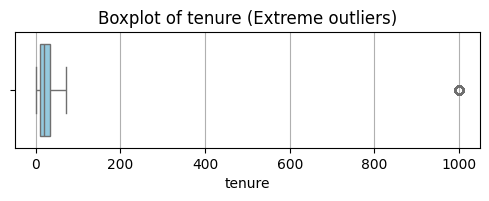

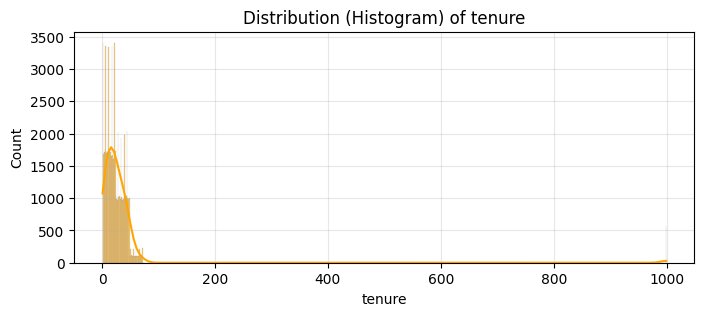


 📌 Extreme outliers in MonthlyCharges: 835 rows


,MonthlyCharges
5571,1499.77
17175,1496.44
23332,1495.16
30163,1494.32
26516,1494.25
2128,1493.74
57755,1493.53
21654,1492.49
64494,1491.82
21432,1491.34


count    67833.000000
mean        60.546252
std        111.374165
min         18.000000
25%         29.670000
50%         41.160000
75%         63.840000
max       1499.770000
Name: MonthlyCharges, dtype: float64

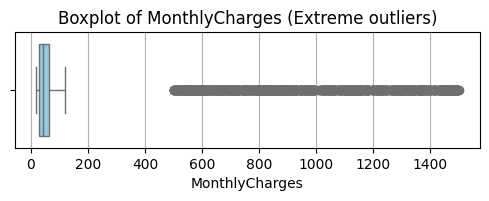

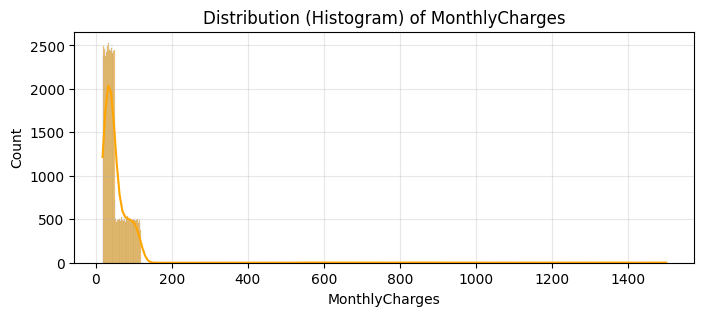


 📌 Extreme outliers in TotalCharges: 1889 rows


,TotalCharges
17635,1254634.11
1140,1244434.32
53134,1009789.20
5357,861467.67
66276,677082.24
54695,574415.01
52689,117872.01
69437,117852.03
15848,117102.78
13235,117092.79


count    6.783300e+04
mean     1.862495e+03
std      1.085057e+04
min      1.500000e+00
25%      4.022200e+02
50%      8.409600e+02
75%      1.559950e+03
max      1.254634e+06
Name: TotalCharges, dtype: float64

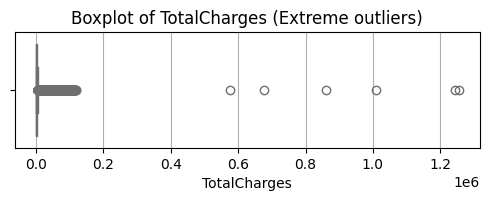

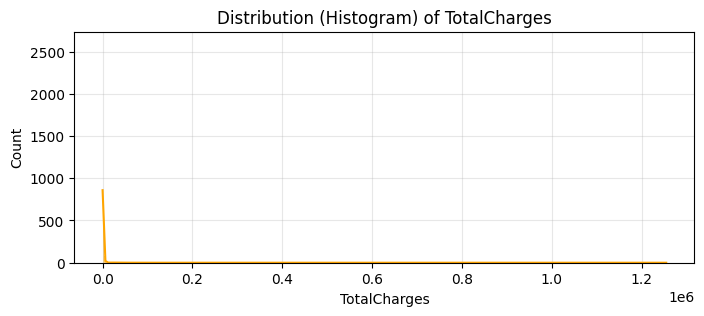

In [177]:
investigate_outliers(df_telco_clean)

### Treating for potential outliers in the tenure column

- It seems like there are abnormaly  high values for tenure
- These values are 999 months which corresponds approximately to 80 years
- There are 571 rows concerned
- 80 years of tenure is almost impossible in reality
- We are going to drop these values and check back the distributions of numerical variables

In [178]:
# Showing the length of the DataFrame before dropping
len(df_telco_clean)

67833

In [179]:
# Dropping values equal to and above 999 in the tenure column
df_telco_clean = df_telco_clean[df_telco_clean["tenure"] < 999]

# Length after cleaning
len(df_telco_clean)

67262


 📌 Extreme outliers in MonthlyCharges: 829 rows


,MonthlyCharges
5571,1499.77
17175,1496.44
23332,1495.16
30163,1494.32
26516,1494.25
2128,1493.74
57755,1493.53
21654,1492.49
64494,1491.82
21432,1491.34


count    67262.000000
mean        60.567156
std        111.480170
min         18.000000
25%         29.670000
50%         41.170000
75%         63.850000
max       1499.770000
Name: MonthlyCharges, dtype: float64

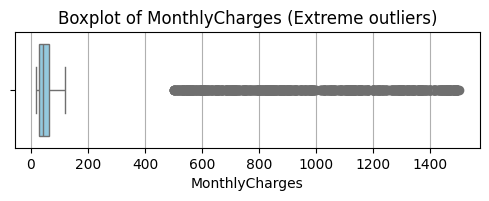

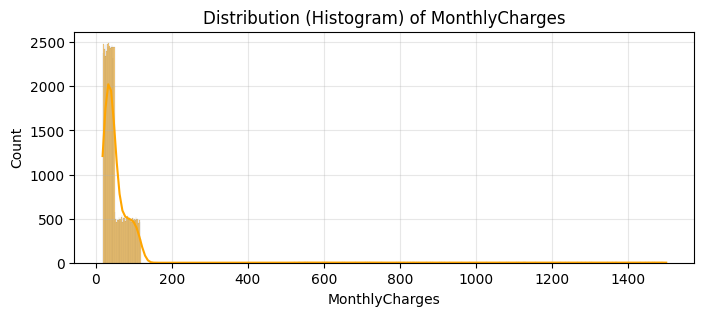


 📌 Extreme outliers in TotalCharges: 1388 rows


,TotalCharges
57755,104547.10
60945,90019.08
7022,88383.75
61800,85866.88
48716,82840.95
20164,81714.78
69168,78184.36
2128,74687.00
29784,73397.19
10809,72570.68


count     67262.000000
mean       1386.384725
std        3208.299891
min           1.500000
25%         398.712500
50%         832.570000
75%        1534.020000
max      104547.100000
Name: TotalCharges, dtype: float64

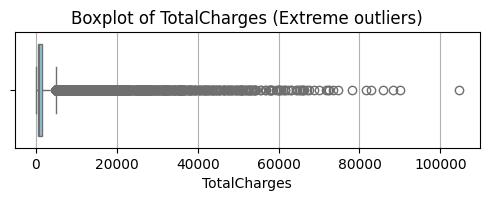

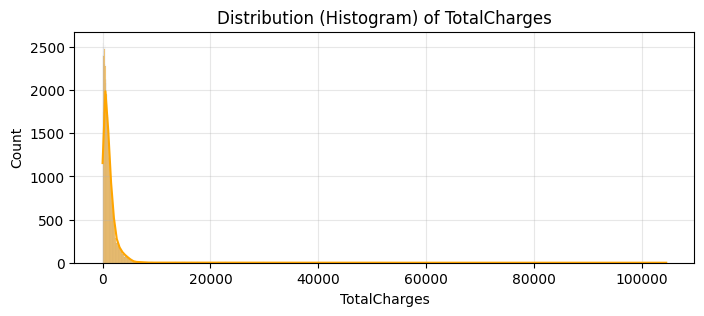

In [180]:
# Checking back the distribution of numerical variables
investigate_outliers(df_telco_clean)

### Treating for potential outliers in the MonthlyCharges column

- After dealing with the outliers in the tenure column and revisiting the distributions we can see that there are still abnormally high values the MonthlyCharges column
- For a typical household, monthly charges shouldn't be more than 200 dollars
- We are now going to exclude these values from the dataset

In [184]:
# Dropping values equal to and above 999 in the tenure column
df_telco_clean = df_telco_clean[df_telco_clean["MonthlyCharges"] <= 200]

# Length after cleaning
len(df_telco_clean)

66433


 📌 Extreme outliers in TotalCharges: 778 rows


,TotalCharges
17256,8459.28
60382,8393.76
1283,8377.29
21376,8377.29
53737,8367.84
25003,8257.90
34427,8256.24
15861,8235.29
31289,8197.66
358,8119.92


count    66433.000000
mean      1121.961306
std       1049.504932
min          1.500000
25%        394.440000
50%        820.040000
75%       1499.400000
max       8459.280000
Name: TotalCharges, dtype: float64

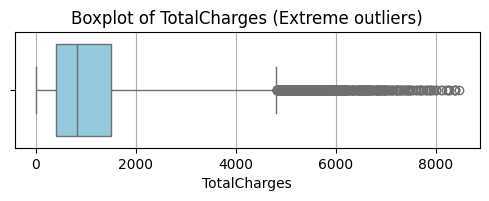

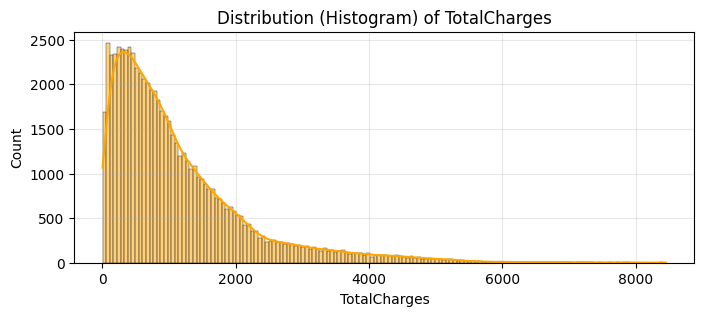

In [185]:
# Checking back the distribution of numerical variables
investigate_outliers(df_telco_clean)

### Treating for potential outliers in the TotalCharges column

In [194]:
# Getting general sense extremly large values for the column
df_telco_clean[df_telco_clean["TotalCharges"] > 8000][["tenure", "MonthlyCharges", "TotalCharges"]] \
    .sort_values("tenure", ascending=True).head(10)

,tenure,MonthlyCharges,TotalCharges
358,69.0,117.68,8119.92
19208,69.0,117.55,8110.95
30401,69.0,116.12,8012.28
25003,70.0,117.97,8257.90
1283,71.0,117.99,8377.29
15861,71.0,115.99,8235.29
21376,71.0,117.99,8377.29
31289,71.0,115.46,8197.66
17256,72.0,117.49,8459.28
34427,72.0,114.67,8256.24


In [192]:
df_telco_clean[(df_telco_clean["TotalCharges"] > 6000) & (df_telco_clean["TotalCharges"] < 8000)] \
    [["tenure", "MonthlyCharges", "TotalCharges"]].sort_values("tenure", ascending=True).head(10)

,tenure,MonthlyCharges,TotalCharges
15562,52.0,117.78,6124.56
49244,52.0,117.46,6107.92
64447,52.0,116.84,6075.68
41850,52.0,117.55,6112.60
65071,53.0,114.90,6089.70
67935,54.0,111.37,6013.98
34659,55.0,109.28,6010.40
16640,55.0,109.91,6045.05
10506,55.0,114.61,6303.55
37240,55.0,114.51,6298.05


In [193]:
df_telco_clean[(df_telco_clean["TotalCharges"] > 6000) & (df_telco_clean["TotalCharges"] < 8000)] \
    [["tenure", "MonthlyCharges", "TotalCharges"]].sort_values("MonthlyCharges", ascending=True).head(10)

,tenure,MonthlyCharges,TotalCharges
37202,72.0,84.03,6050.16
3811,72.0,84.55,6087.60
68174,72.0,85.00,6120.00
58514,72.0,85.76,6174.72
9936,72.0,85.84,6180.48
20819,72.0,86.53,6230.16
12036,71.0,86.71,6156.41
43899,72.0,86.72,6243.84
23509,70.0,86.78,6074.60
8999,71.0,86.87,6167.77


- From the above, we can conclude that outliers on the TotalCharges column make sense
- We are not going to remove them

# Viewing info on final DataFrame and exporting the data

In [195]:
# Viewing info
df_telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66433 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        66433 non-null  object 
 1   gender            66433 non-null  object 
 2   SeniorCitizen     66433 non-null  Int8   
 3   Partner           66433 non-null  Int8   
 4   Dependents        66433 non-null  Int8   
 5   tenure            66433 non-null  float64
 6   PhoneService      66433 non-null  Int8   
 7   MultipleLines     66433 non-null  object 
 8   InternetService   66433 non-null  object 
 9   OnlineSecurity    66433 non-null  object 
 10  OnlineBackup      66433 non-null  object 
 11  DeviceProtection  66433 non-null  object 
 12  TechSupport       66433 non-null  object 
 13  StreamingTV       66433 non-null  object 
 14  StreamingMovies   66433 non-null  object 
 15  Contract          66433 non-null  object 
 16  PaperlessBilling  66433 non-null  Int8   
 17

In [198]:
# Exporting the cleaned
df_telco_clean.to_csv("/Users/igor_laminsi/Documents/data_science_portfolio_projects"
"/telcoconnect-churn/data/cleaned_telco.csv", index=False)